# 01 — EDA: JSE Equities + Macro
Exploratory analysis of the master dataset produced by the jse-radar pipeline.
We load the processed master parquet and examine structure, distributions,
price history, and first macro correlations.

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# Load config so we always use the correct paths
import sys
sys.path.insert(0, str(Path("..").resolve() / "src"))
from jse_radar.config import PROC_MASTER_DIR, PROC_EQUITY_DIR, PROC_MACRO_DIR

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
print("Imports OK")

Imports OK


In [3]:
# Find and load the latest master parquet
master_files = sorted(PROC_MASTER_DIR.glob("master_*.parquet"))
if not master_files:
    raise FileNotFoundError("No master parquet found. Run the pipeline first.")

master = pd.read_parquet(master_files[-1])
master["date"] = pd.to_datetime(master["date"])

print(f"Master frame shape: {master.shape}")
print(f"Date range: {master['date'].min().date()} → {master['date'].max().date()}")
print(f"Tickers: {sorted(master['ticker'].unique())}")
print(f"\nColumns:\n{list(master.columns)}")

Master frame shape: (79513, 29)
Date range: 2015-01-01 → 2026-06-11
Tickers: ['ABG.JO', 'AGL.JO', 'APN.JO', 'BTI.JO', 'BVT.JO', 'DSY.JO', 'FSR.JO', 'GFI.JO', 'GRT.JO', 'HAR.JO', 'IMP.JO', 'MRP.JO', 'MTN.JO', 'NED.JO', 'NPN.JO', 'PIK.JO', 'PRX.JO', 'RDF.JO', 'SBK.JO', 'SLM.JO', 'SOL.JO', 'SPP.JO', 'TBS.JO', 'TRU.JO', 'VOD.JO', 'WHL.JO', '^J203.JO', '^J400.JO']

Columns:
['date', 'ticker', 'Adj Close', 'close', 'high', 'low', 'open', 'volume', 'name', 'daily_return', 'log_return', 'volatility_21d', 'high_52w', 'low_52w', 'pct_from_52w_high', 'year', 'month', 'quarter', 'day_of_week', 'zar_usd', 'usd_eur', 'repo_rate', 'cpi_all', 'cpi_core', 'exports_value', 'imports_value', 'zar_usd_mom_pct', 'cpi_yoy_pct', 'real_repo_rate']


## 1. Data quality check
Before any analysis, we check for missing values and confirm the
structure is what we expect.

In [4]:
# What percentage of each column is missing?
missing = (master.isnull().sum() / len(master) * 100).round(2)
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values (% of rows):")
print(missing.to_string())

print(f"\nRows per ticker:")
print(master.groupby("ticker")["date"].count().sort_values(ascending=False).to_string())

Columns with missing values (% of rows):
Adj Close           100.0000
real_repo_rate      100.0000
repo_rate           100.0000
cpi_yoy_pct          18.5500
cpi_core             10.5000
cpi_all               9.7200
high_52w              1.7300
pct_from_52w_high     1.7300
low_52w               1.7300
zar_usd_mom_pct       1.4200
zar_usd               0.7400
exports_value         0.7400
usd_eur               0.7400
imports_value         0.7400
volatility_21d        0.3500
log_return            0.0400
daily_return          0.0400

Rows per ticker:
ticker
ABG.JO      2888
AGL.JO      2888
APN.JO      2888
BTI.JO      2888
BVT.JO      2888
DSY.JO      2888
FSR.JO      2888
GFI.JO      2888
GRT.JO      2888
HAR.JO      2888
IMP.JO      2888
MRP.JO      2888
MTN.JO      2888
NED.JO      2888
NPN.JO      2888
PIK.JO      2888
RDF.JO      2888
SBK.JO      2888
SLM.JO      2888
SOL.JO      2888
VOD.JO      2888
SPP.JO      2888
TBS.JO      2888
TRU.JO      2888
WHL.JO      2888
^J203.JO    2869

## 2. Price history — key stocks
Visual check that prices look sensible. We plot adjusted close for
a selection of stocks across different sectors.

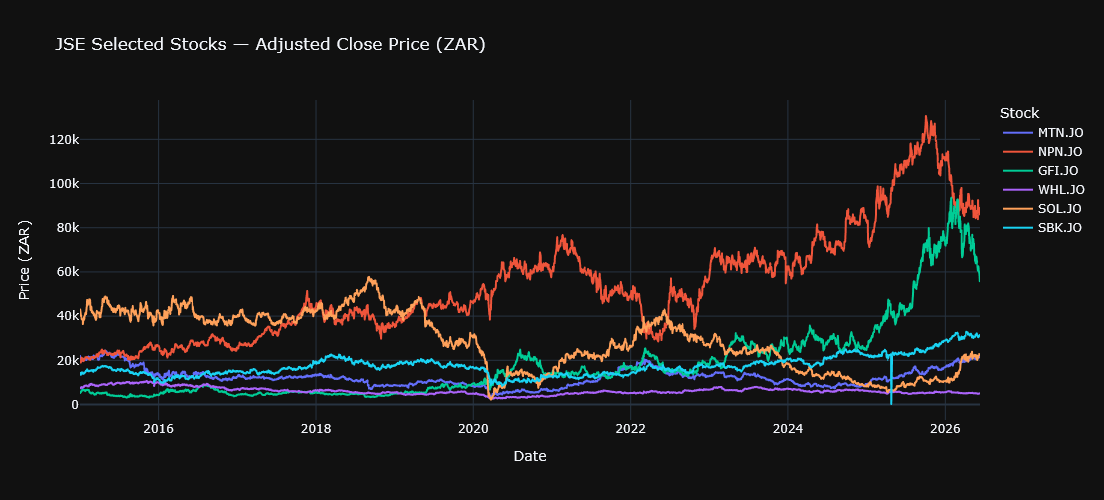

In [5]:
# Select a representative cross-section of sectors
watch = ["NPN.JO", "SBK.JO", "SOL.JO", "GFI.JO", "MTN.JO", "WHL.JO"]
df_watch = master[master["ticker"].isin(watch)].copy()

fig = px.line(
    df_watch,
    x="date",
    y="close",
    color="ticker",
    title="JSE Selected Stocks — Adjusted Close Price (ZAR)",
    labels={"close": "Price (ZAR)", "date": "Date", "ticker": "Stock"},
    template="plotly_dark",
)
fig.update_layout(height=500, hovermode="x unified")
fig.show()

## 3. Return distributions
Daily returns should be approximately normal with fat tails.
Any stock with extreme skew or outliers needs investigation.

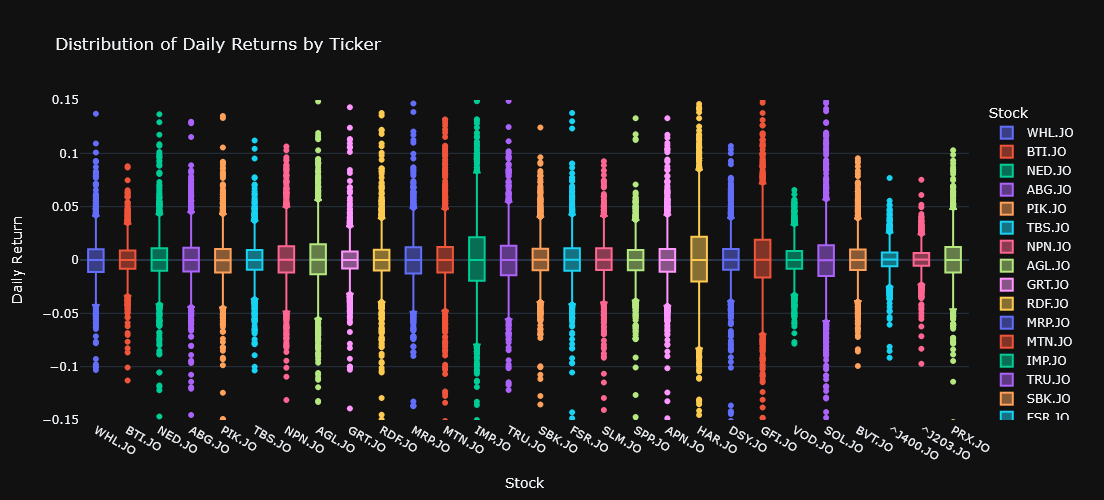

            mean     std    skew     min      max
ticker                                           
ABG.JO    0.0003  0.0211 -0.0076 -0.1554   0.1848
AGL.JO    0.0008  0.0265  0.2721 -0.1332   0.1892
APN.JO   -0.0001  0.0234 -0.9397 -0.3071   0.2418
BTI.JO    0.0003  0.0156 -0.1510 -0.1130   0.0879
BVT.JO    0.0005  0.0185  0.7056 -0.0994   0.1816
DSY.JO    0.0005  0.0201 -0.2726 -0.1510   0.1782
FSR.JO    0.0004  0.0199 -0.0205 -0.1484   0.1378
GFI.JO    0.0014  0.0338  0.1476 -0.2041   0.2106
GRT.JO   -0.0000  0.0173 -0.2077 -0.1715   0.1431
HAR.JO    0.0015  0.0371  0.3222 -0.1800   0.2404
IMP.JO    0.0010  0.0369  0.2059 -0.2392   0.2174
MRP.JO    0.0001  0.0230 -0.1834 -0.1782   0.1467
MTN.JO    0.0003  0.0257 -0.1236 -0.1941   0.1919
NED.JO    0.0002  0.0209 -0.0194 -0.1578   0.1367
NPN.JO    0.0008  0.0239  0.3313 -0.1770   0.2279
PIK.JO   -0.0001  0.0214 -0.1593 -0.1602   0.1350
PRX.JO    0.0005  0.0243  0.3546 -0.1739   0.2107
RDF.JO    0.0001  0.0250  0.6944 -0.2636   0.2768


In [7]:
# Box plot of daily returns per ticker — quickly shows outliers
fig = px.box(
    master.dropna(subset=["daily_return"]),
    x="ticker",
    y="daily_return",
    title="Distribution of Daily Returns by Ticker",
    color = 'ticker',
    labels={"daily_return": "Daily Return", "ticker": "Stock"},
    template="plotly_dark",
)
fig.update_layout(height=500)
fig.update_yaxes(range=[-0.15, 0.15])
fig.show()

# Summary statistics
print(master.groupby("ticker")["daily_return"].agg(
    ["mean", "std", "skew", "min", "max"]
).round(4).to_string())

## 4. Macro indicators over time
Check that our FRED series loaded correctly and cover the full date range.

In [9]:
# Diagnostic — inspect raw macro values
macro_files = sorted(PROC_MACRO_DIR.glob("macro_processed_*.parquet"))
macro = pd.read_parquet(macro_files[-1])
macro["date"] = pd.to_datetime(macro["date"])

print("Shape:", macro.shape)
print("\nColumns:", list(macro.columns))
print("\nFirst 10 rows:")
print(macro.head(10).to_string())
print("\nRepo rate stats:")
print(macro["repo_rate"].describe())
print("\nNon-null repo rate count:", macro["repo_rate"].notna().sum())
print("\nSample repo rate values:")
print(macro[["date", "repo_rate"]].dropna().head(20).to_string())

Shape: (138, 11)

Columns: ['date', 'zar_usd', 'usd_eur', 'repo_rate', 'cpi_all', 'cpi_core', 'exports_value', 'imports_value', 'zar_usd_mom_pct', 'cpi_yoy_pct', 'real_repo_rate']

First 10 rows:
        date  zar_usd  usd_eur  repo_rate  cpi_all  cpi_core    exports_value    imports_value  zar_usd_mom_pct  cpi_yoy_pct  real_repo_rate
0 2015-01-31  11.5527   1.1615        NaN  96.6855   97.0363 80044600000.0000 93307140000.0000              NaN          NaN             NaN
1 2015-02-28  11.5773   1.1350        NaN  97.3143   98.2622 82771770000.0000 91523520000.0000           0.2135          NaN             NaN
2 2015-03-31  12.0884   1.0819        NaN  98.5720   99.2204 87271440000.0000 90549480000.0000           4.4142          NaN             NaN
3 2015-04-30  11.9755   1.0822        NaN  99.5153   99.5452 87296420000.0000 88230170000.0000          -0.9338          NaN             NaN
4 2015-05-31  11.9720   1.1167        NaN  99.6725   99.6545 90261540000.0000 89181370000.0000     

In [10]:
# Check the RAW macro file directly
from jse_radar.config import RAW_MACRO_DIR

raw_files = sorted(RAW_MACRO_DIR.glob("macro_*.parquet"))
raw = pd.read_parquet(raw_files[-1])
raw["date"] = pd.to_datetime(raw["date"])

print("Raw shape:", raw.shape)
print("\nRepo rate in raw file:")
print(raw[["date", "repo_rate"]].dropna().head(30).to_string())
print("\nRepo rate stats:")
print(raw["repo_rate"].describe())

Raw shape: (3021, 8)

Repo rate in raw file:
Empty DataFrame
Columns: [date, repo_rate]
Index: []

Repo rate stats:
count   0.0000
mean       NaN
std        NaN
min        NaN
25%        NaN
50%        NaN
75%        NaN
max        NaN
Name: repo_rate, dtype: float64


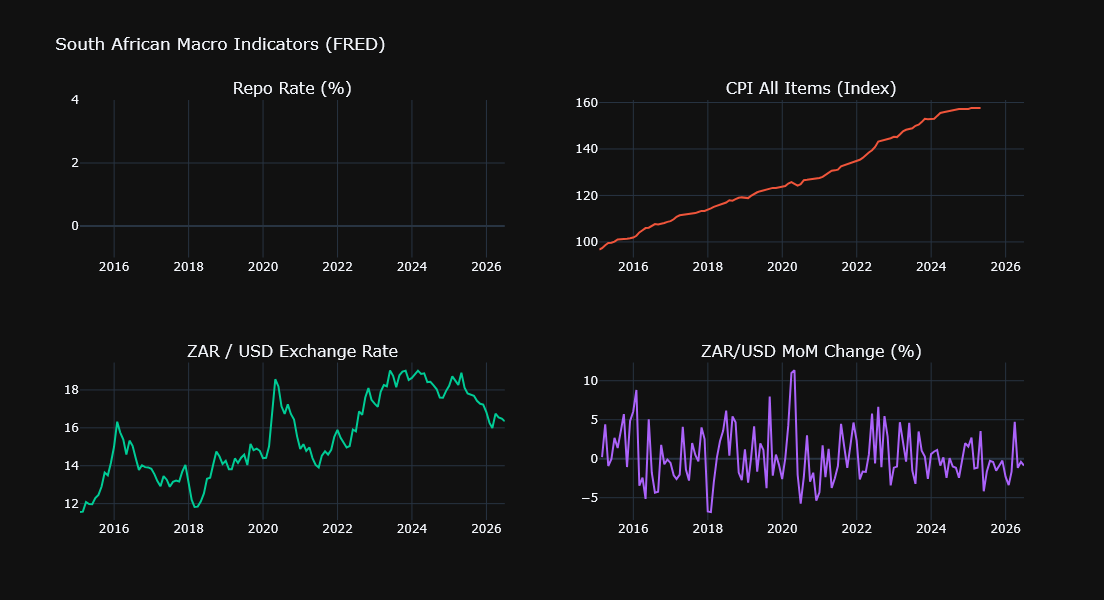

In [8]:
# Load the processed macro directly for a clean view
macro_files = sorted(PROC_MACRO_DIR.glob("macro_processed_*.parquet"))
macro = pd.read_parquet(macro_files[-1])
macro["date"] = pd.to_datetime(macro["date"])

# Plot the four most important macro series
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        "Repo Rate (%)",
        "CPI All Items (Index)",
        "ZAR / USD Exchange Rate",
        "ZAR/USD MoM Change (%)",
    ]
)

series = [
    ("repo_rate",       1, 1),
    ("cpi_all",         1, 2),
    ("zar_usd",         2, 1),
    ("zar_usd_mom_pct", 2, 2),
]

for col, row, col_pos in series:
    if col in macro.columns:
        fig.add_trace(
            go.Scatter(x=macro["date"], y=macro[col], name=col, mode="lines"),
            row=row, col=col_pos,
        )

fig.update_layout(
    height=600,
    title="South African Macro Indicators (FRED)",
    template="plotly_dark",
    showlegend=False,
)
fig.show()